# 🧴 Análisis Exploratorio de Datos (EDA) - Base de Cosmética

Este notebook tiene como objetivo analizar la base de datos `db_cosmetica.db` para entender la calidad y distribución de los datos que alimentan nuestro sistema RAG.

**Objetivos:**
1. **Inspección Inicial:** Cargar los datos y revisar su estructura, tipos y valores nulos.
2. **Análisis de Textos:** Evaluar la longitud y calidad de las descripciones e ingredientes.
3. **Análisis de Ingredientes:** Identificar los ingredientes más comunes para mejorar nuestro filtro de intención.
4. **Verificación de Embeddings:** Asegurar que los vectores de embedding son consistentes.
5. **Conclusiones:** Extraer insights accionables para mejorar el asistente Kim.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np

# Configuración de estilo para las visualizaciones
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Nombre de la base de datos
DB_NAME = 'db_cosmetica.db'

## 1. Carga e Inspección Inicial de Datos

In [2]:
try:
    conn = sqlite3.connect(DB_NAME)
    df = pd.read_sql_query("SELECT * FROM productos_scraped", conn)
    conn.close()
    print(f"✅ Base de datos cargada con éxito. Total de productos: {len(df)}")
except Exception as e:
    print(f"❌ Error al leer la base de datos: {e}")

# Revisión inicial de la estructura y datos nulos
print("\n--- Información del DataFrame ---")
df.info()

print("\n--- Valores Nulos por Columna ---")
print(df.isnull().sum())

print("\n--- Primeras 5 Filas ---")
df.head()

✅ Base de datos cargada con éxito. Total de productos: 9684

--- Información del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9684 entries, 0 to 9683
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   nombre            9684 non-null   object
 1   descripcion       9684 non-null   object
 2   ingredientes      9684 non-null   object
 3   embedding_vector  9684 non-null   object
dtypes: object(4)
memory usage: 302.8+ KB

--- Valores Nulos por Columna ---
nombre              0
descripcion         0
ingredientes        0
embedding_vector    0
dtype: int64

--- Primeras 5 Filas ---


,nombre,descripcion,ingredientes,embedding_vector
0,Máscara de pestañas LancÃ´me Definicils - 01 N...,Abra su mirada con la máscara de pestañas Lanc...,N/A,"[1.2571375370025635, 0.21864013373851776, -2.2..."
1,Champú 1St Lather deÂ KeracareÂ (240 ml),Limpie la suciedad y los residuos de su cabell...,N/A,"[0.6710900068283081, 1.2570379972457886, -3.63..."
2,Conjunto Petite de Pinzas en Funda de Cuero de...,Todo lo necesario para la depilación con pinza...,N/A,"[1.0091849565505981, 0.7206931710243225, -2.80..."
3,Peine de pestañas Tweezerman iLashcombâ¢,El peine de pestañas Tweezerman iLashcombâ¢ e...,N/A,"[1.1006077527999878, 0.5128189921379089, -2.96..."
4,Crema para el contorno de ojos deÂ Skin Doctor...,Reduzca drásticamente las bolsas y las ojeras ...,N/A,"[0.15082097053527832, 1.794231653213501, -3.08..."


## 2. Análisis de Longitud de Textos

La longitud de las descripciones y listas de ingredientes es crucial. Textos muy cortos pueden generar embeddings de baja calidad y limitar el contexto que le damos al LLM.

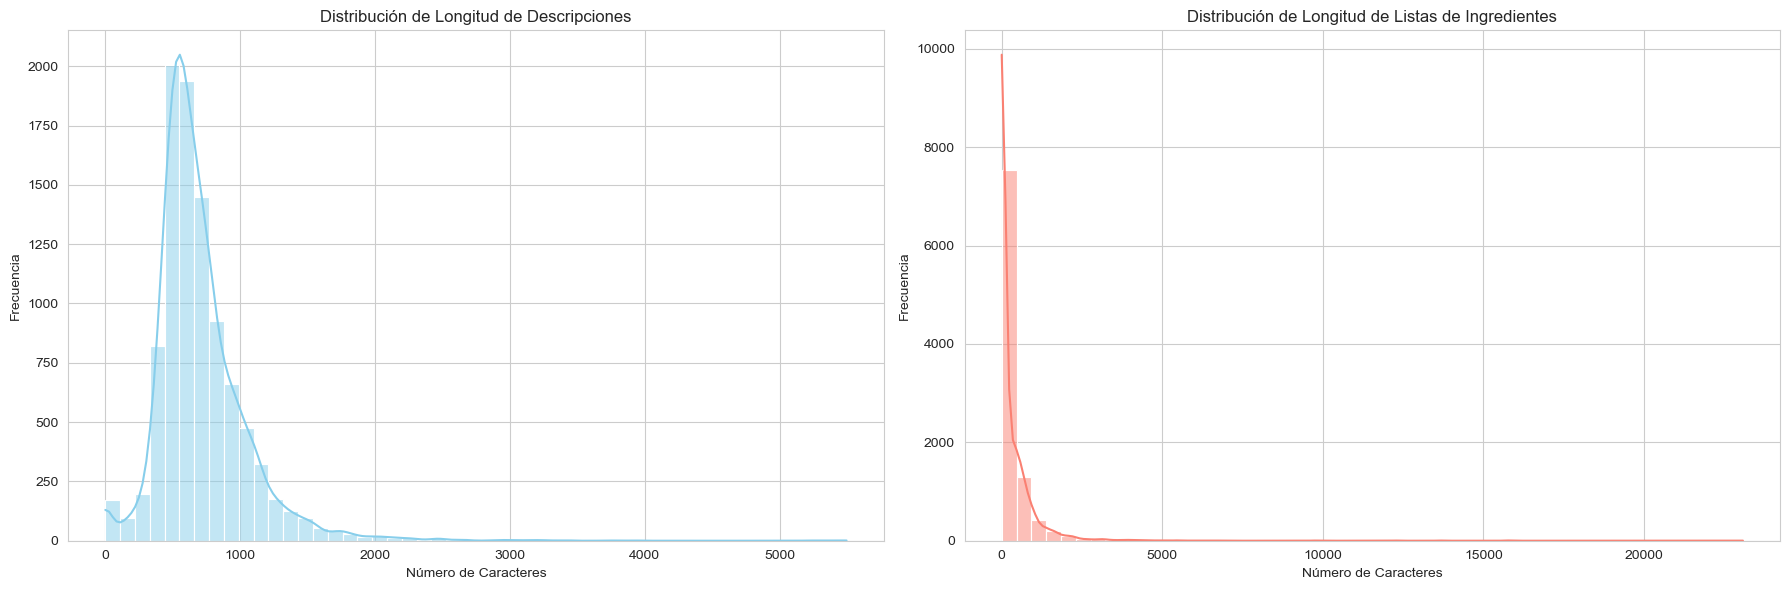

In [3]:
# Calculamos la longitud (número de caracteres) de las descripciones y los ingredientes
df['descripcion_len'] = df['descripcion'].str.len()
df['ingredientes_len'] = df['ingredientes'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(df['descripcion_len'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Longitud de Descripciones')
axes[0].set_xlabel('Número de Caracteres')
axes[0].set_ylabel('Frecuencia')

sns.histplot(df['ingredientes_len'], bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución de Longitud de Listas de Ingredientes')
axes[1].set_xlabel('Número de Caracteres')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 3. Análisis de Ingredientes

Este es el análisis más importante para mejorar nuestro sistema. Vamos a extraer todos los ingredientes individuales para identificar los más comunes. **La lista resultante puede usarse para refinar el filtro `is_technical_query` en `app.py`.**

In [4]:
# Limpiamos y contamos la frecuencia de cada ingrediente
# Asumimos que están separados por comas
ingredient_counts = df['ingredientes'].str.split(',').explode().str.strip().str.upper().value_counts()

print("--- Top 30 Ingredientes Más Comunes ---")
top_30_ingredients = ingredient_counts.head(30)
print(top_30_ingredients)

--- Top 30 Ingredientes Más Comunes ---
ingredientes
N/A                             5826
GLYCERIN                        2228
PHENOXYETHANOL                  1884
LINALOOL                        1539
LIMONENE                        1526
CITRIC ACID                     1467
TOCOPHEROL                      1405
CAPRYLYL GLYCOL                 1098
SODIUM BENZOATE                  974
DIMETHICONE                      972
CITRONELLOL                      955
BUTYLENE GLYCOL                  949
ETHYLHEXYLGLYCERIN               948
CAPRYLIC/CAPRIC TRIGLYCERIDE     861
GERANIOL                         851
POTASSIUM SORBATE                847
SODIUM HYALURONATE               832
CETEARYL ALCOHOL                 813
DISODIUM EDTA                    797
SODIUM HYDROXIDE                 791
SILICA                           790
XANTHAN GUM                      777
TOCOPHERYL ACETATE               767
BENZYL ALCOHOL                   763
CITRAL                           642
PROPYLENE GLYCOL      

/tmp/ipykernel_43768/3103679923.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_30_ingredients.head(20).values, y=top_30_ingredients.head(20).index, palette='mako')


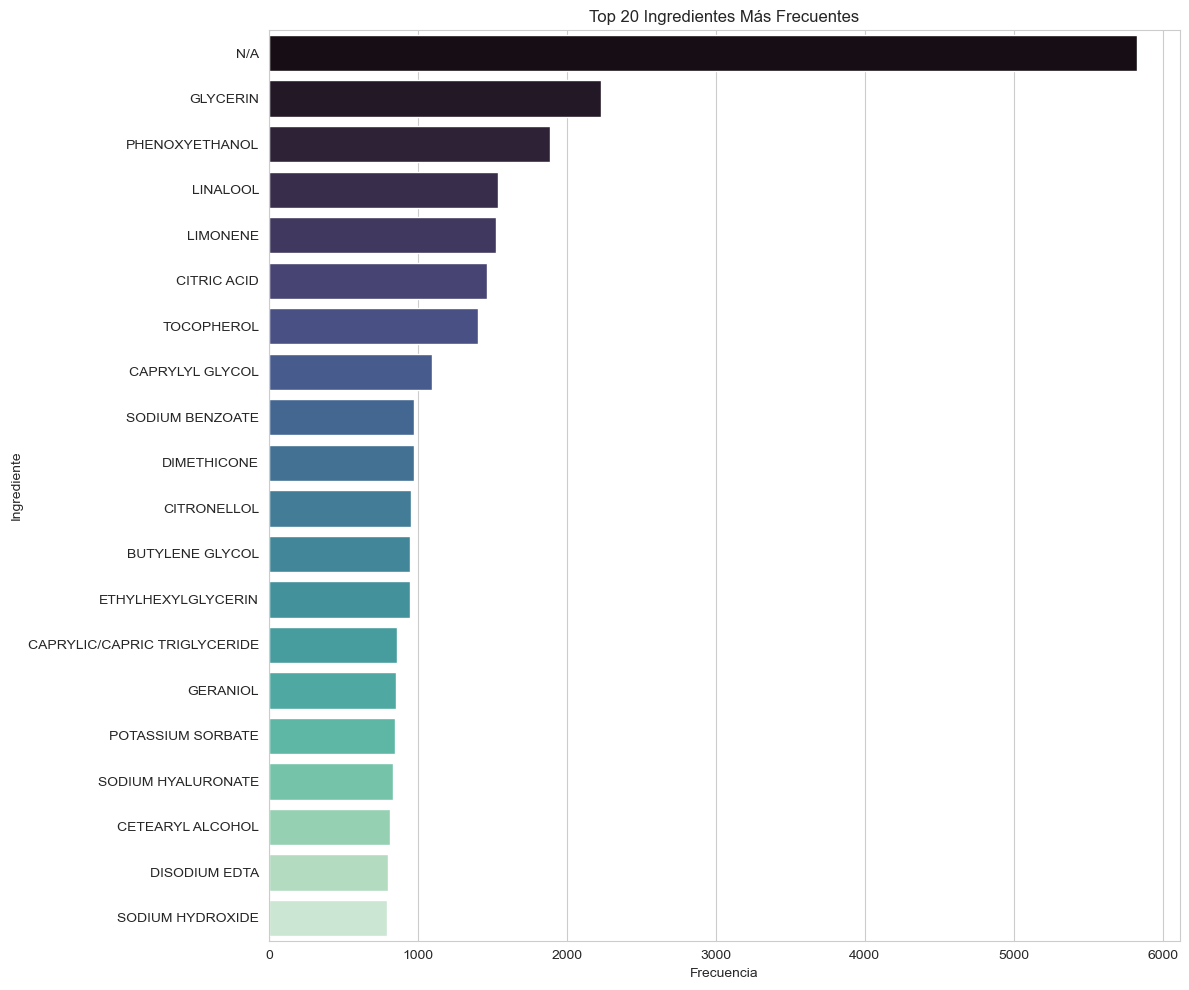

In [5]:
# Visualizamos el Top 20
plt.figure(figsize=(12, 10))
sns.barplot(x=top_30_ingredients.head(20).values, y=top_30_ingredients.head(20).index, palette='mako')
plt.title('Top 20 Ingredientes Más Frecuentes')
plt.xlabel('Frecuencia')
plt.ylabel('Ingrediente')
plt.tight_layout()
plt.show()

## 4. Verificación de Embeddings

Vamos a realizar una comprobación de sanidad para asegurarnos de que todos los vectores de embedding tienen la misma dimensión. Esto es crucial para que los cálculos de similitud de coseno funcionen correctamente.

In [6]:
def get_embedding_dim(vector_blob):
    try:
        # El vector está guardado como un string JSON
        return len(json.loads(vector_blob))
    except (json.JSONDecodeError, TypeError):
        return 0 # Devuelve 0 si hay algún error o está vacío

df['embedding_dim'] = df['embedding_vector'].apply(get_embedding_dim)

print("--- Dimensiones de los Vectores de Embedding Encontradas ---")
print(df['embedding_dim'].value_counts())

# Deberíamos ver un solo número (la dimensión de 'nomic-embed-text') con un conteo igual al total de productos.

--- Dimensiones de los Vectores de Embedding Encontradas ---
embedding_dim
768    9684
Name: count, dtype: int64


## 1.b. Análisis Específico de Valores 'N/A'

Como mencionaste, es crucial investigar la presencia del string `'N/A'` en la columna `ingredientes`. Un valor `'N/A'` es un dato faltante (nulo) que el scraper ha guardado como texto.

La siguiente celda contará cuántos productos tienen este problema. Un número alto aquí indica una baja calidad de datos que afectará directamente a las respuestas de Kim.

In [7]:
print("Buscando valores 'N/A' en la columna 'ingredientes'...")

# Definimos el string que buscamos
na_string = 'N/A'

# Filtramos el DataFrame para encontrar filas donde 'ingredientes' es exactamente 'N/A'
na_df = df[df['ingredientes'] == na_string]
na_counts = len(na_df)
total_productos = len(df)

if na_counts > 0:
    porcentaje = (na_counts / total_productos) * 100
    
    print(f"\n🚨 ¡Alerta! Se encontraron {na_counts} productos donde la lista de ingredientes es '{na_string}'.")
    print(f"   Esto representa el {porcentaje:.2f}% del total de tus productos.")
    
    print("\n--- Ejemplo de 5 productos con ingredientes 'N/A' ---")
    # Usamos .head() para mostrar solo los primeros 5 ejemplos
    print(na_df[['nombre', 'ingredientes']].head())
else:
    print("\n✅ ¡Excelente! No se encontraron valores 'N/A' en la columna de ingredientes.")

Buscando valores 'N/A' en la columna 'ingredientes'...

🚨 ¡Alerta! Se encontraron 5826 productos donde la lista de ingredientes es 'N/A'.
   Esto representa el 60.16% del total de tus productos.

--- Ejemplo de 5 productos con ingredientes 'N/A' ---
                                              nombre ingredientes
0  Máscara de pestañas LancÃ´me Definicils - 01 N...          N/A
1           Champú 1St Lather deÂ KeracareÂ (240 ml)          N/A
2  Conjunto Petite de Pinzas en Funda de Cuero de...          N/A
3          Peine de pestañas Tweezerman iLashcombâ¢          N/A
4  Crema para el contorno de ojos deÂ Skin Doctor...          N/A


## 5. Conclusiones y Pasos a Seguir 🚀

Basado en este análisis, podemos extraer las siguientes conclusiones y acciones:

1.  **Calidad de los Datos:**
    * *Revisa la sección de valores nulos.* Si hay muchos, considera mejorar tu scraper para que sea más robusto o para que descarte productos sin información clave (como ingredientes).

2.  **Calidad del Texto:**
    * *Observa los histogramas de longitud.* Si hay muchos productos con descripciones muy cortas (ej. menos de 100 caracteres), la calidad del RAG podría verse afectada. Podrías necesitar buscar fuentes de datos con descripciones más detalladas.

3.  **¡ACCIÓN CRÍTICA! - Mejora del Filtro de Intención:**
    * **Copia la lista del Top 30 de ingredientes** que generamos en la celda 8.
    * **Ve a tu archivo `app.py` y reemplaza la lista `technical_patterns`** en la función `is_technical_query` con esta nueva lista, que está basada en TUS DATOS REALES. Esto hará que el filtro sea mucho más preciso.
    * Ejemplo de cómo debería quedar en `app.py`:
    ```python
    # app.py -> is_technical_query()
    technical_patterns = [
        'AQUA', 'GLYCERIN', 'BUTYLENE GLYCOL', 'SODIUM HYALURONATE', # ...y así sucesivamente
    ]
    ```

4.  **Consistencia de Embeddings:**
    * *Revisa la salida de la celda 11.* Si ves múltiples dimensiones o valores de 0, significa que algunos embeddings no se generaron correctamente. Deberías volver a ejecutar tu script de scraping/embedding para esos productos específicos.